# AI-Guided Protein Engineering:
## Predicting and Ranking Protein Mutations Using Protein Language Models

### Project Objective

Protein engineering often requires identifying amino-acid mutations that improve
protein function, stability, binding, or other desirable properties.

Experimentally testing every possible mutation is expensive and time-consuming.

In this project, I investigate whether representations learned by a pretrained
protein language model, ESM-2, can be used with supervised machine learning to
predict experimentally measured protein mutation fitness.

The workflow is:

1. Load experimentally measured protein mutations.
2. Analyze the mutation fitness landscape.
3. Encode protein sequences using ESM-2.
4. Train a machine-learning model using ESM-2 embeddings.
5. Predict mutation fitness on unseen variants.
6. Rank promising protein mutations.
7. Evaluate predictive performance using multiple metrics.

In [1]:
!pip install -q transformers torch scikit-learn pandas numpy matplotlib tqdm

In [2]:
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
!git clone -q https://github.com/OATML-Markslab/ProteinGym.git

In [4]:
import os

print(os.listdir("ProteinGym")[:20])

['notebooks', 'config.json', 'setup.py', 'LICENSE', 'scripts', 'reference_files', '.gitignore', '.git', 'assays.bib', 'benchmarks', 'environments', 'README.md', 'proteingym']


In [5]:
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm_model = AutoModel.from_pretrained(MODEL_NAME)

esm_model = esm_model.to(device)
esm_model.eval()

print("Loaded:", MODEL_NAME)
print("Device:", device)

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 31.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: facebook/esm2_t6_8M_UR50D
Device: cuda


In [6]:
test_sequence = "MKTIIALSYIFCLVFADYKDDDDK"

inputs = tokenizer(
    test_sequence,
    return_tensors="pt",
    add_special_tokens=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = esm_model(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([1, 26, 320])


In [7]:
def get_esm_embedding(sequence):
    """
    Convert a protein amino-acid sequence into a fixed-length
    ESM-2 embedding using mean pooling.
    """

    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = esm_model(**inputs)

    hidden_states = outputs.last_hidden_state

    # Remove beginning and ending special tokens
    residue_embeddings = hidden_states[:, 1:-1, :]

    # Average all amino-acid embeddings
    sequence_embedding = residue_embeddings.mean(dim=1)

    return sequence_embedding.squeeze(0).cpu().numpy()

In [8]:
embedding = get_esm_embedding(test_sequence)

print("Embedding shape:", embedding.shape)
print(embedding[:10])

Embedding shape: (320,)
[-0.07358816  0.25978547  0.134232    0.13769828 -0.09440377  0.03100498
 -0.06261185 -0.37583205 -0.01427447  0.11544373]


In [9]:
reference_path = "ProteinGym/reference_files/DMS_substitutions.csv"

reference_df = pd.read_csv(reference_path)

print("Number of assays:", len(reference_df))
print(reference_df.columns.tolist())

reference_df.head()

Number of assays: 217
['DMS_index', 'DMS_id', 'DMS_filename', 'UniProt_ID', 'taxon', 'source_organism', 'target_seq', 'seq_len', 'includes_multiple_mutants', 'DMS_total_number_mutants', 'DMS_number_single_mutants', 'DMS_number_multiple_mutants', 'DMS_binarization_cutoff', 'DMS_binarization_method', 'first_author', 'title', 'year', 'jo', 'region_mutated', 'molecule_name', 'selection_assay', 'selection_type', 'MSA_filename', 'MSA_start', 'MSA_end', 'MSA_len', 'MSA_bitscore', 'MSA_theta', 'MSA_num_seqs', 'MSA_perc_cov', 'MSA_num_cov', 'MSA_N_eff', 'MSA_Neff_L', 'MSA_Neff_L_category', 'MSA_num_significant', 'MSA_num_significant_L', 'raw_DMS_filename', 'raw_DMS_phenotype_name', 'raw_DMS_directionality', 'raw_DMS_mutant_column', 'weight_file_name', 'pdb_file', 'pdb_range', 'ProteinGym_version', 'raw_mut_offset', 'coarse_selection_type']


,DMS_index,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
0,DMS_sub_0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423,False,9576,...,A0A140D2T1_ZIKV_Sourisseau_growth_2019.csv,effect,1,mutant,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness
1,DMS_sub_1,A0A192B1T2_9HIV1_Haddox_2018,A0A192B1T2_9HIV1_Haddox_2018.csv,A0A192B1T2_9HIV1,Virus,Human immunodeficiency virus 1,MRVKGIQMNSQHLLRWGIMILGMIMICSVAGNLWVTVYYGVPVWKD...,852,False,12577,...,A0A192B1T2_9HIV1_Haddox_2018.csv,fitness,1,mutant,A0A192B1T2_9HIV1_theta_0.01.npy,A0A192B1T2_9HIV1.pdb,1-852,0.1,NaN,OrganismalFitness
2,DMS_sub_2,A0A1I9GEU1_NEIME_Kennouche_2019,A0A1I9GEU1_NEIME_Kennouche_2019.csv,A0A1I9GEU1_NEIME,Prokaryote,Neisseria meningitidis,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,161,False,922,...,A0A1I9GEU1_NEIME_Kennouche_2019.csv,piliation_log2_ratio,1,mutants,A0A1I9GEU1_NEIME_theta_0.2.npy,A0A1I9GEU1_NEIME.pdb,1-161,0.1,NaN,Activity
3,DMS_sub_3,A0A247D711_LISMN_Stadelmann_2021,A0A247D711_LISMN_Stadelmann_2021.csv,A0A247D711_LISMN,Prokaryote,Listeria monocytogenes,MNINDLIREIKNKDYTVKLSGTDSNSITQLIIRVNNDGNEYVISES...,87,False,1653,...,A0A247D711_LISMN_Stadelmann_2021.csv,mean_prediction,1,mutant,A0A247D711_LISMN_b03_theta_0.2.npy,A0A247D711_LISMN.pdb,1-87,1.0,NaN,Activity
4,DMS_sub_4,A0A2Z5U3Z0_9INFA_Doud_2016,A0A2Z5U3Z0_9INFA_Doud_2016.csv,A0A2Z5U3Z0_9INFA,Virus,Influenza A virus (A/WSN/1933(H1N1)),MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,565,False,10715,...,A0A2Z5U3Z0_9INFA_Doud_2016.csv,transformed_pref,1,mutant,A0A2Z5U3Z0_9INFA_theta_0.01.npy,A0A2Z5U3Z0_9INFA.pdb,1-565,0.1,NaN,OrganismalFitness


In [10]:
search_terms = ["GB1", "SPG1", "Olson"]

mask = reference_df.astype(str).apply(
    lambda col: col.str.contains("|".join(search_terms), case=False, na=False)
).any(axis=1)

gb1_candidates = reference_df[mask]

print("Matching assays:", len(gb1_candidates))

display(gb1_candidates[
    ["DMS_id", "DMS_filename", "UniProt_ID", "target_seq"]
].head(20))

Matching assays: 2


,DMS_id,DMS_filename,UniProt_ID,target_seq
181,SPG1_STRSG_Olson_2014,SPG1_STRSG_Olson_2014.csv,SPG1_STRSG,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...
182,SPG1_STRSG_Wu_2016,SPG1_STRSG_Wu_2016.csv,SPG1_STRSG,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...


In [11]:
if len(gb1_candidates) == 0:
    raise ValueError("No GB1-like assay found. Stop here and send me the output.")

selected_assay = gb1_candidates.iloc[0]

DMS_ID = selected_assay["DMS_id"]
DMS_FILENAME = selected_assay["DMS_filename"]
WT_SEQUENCE = selected_assay["target_seq"]

print("Selected assay:", DMS_ID)
print("Filename:", DMS_FILENAME)
print("Wild-type protein length:", len(WT_SEQUENCE))
print("Wild-type sequence:")
print(WT_SEQUENCE)

Selected assay: SPG1_STRSG_Olson_2014
Filename: SPG1_STRSG_Olson_2014.csv
Wild-type protein length: 448
Wild-type sequence:
MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED


In [12]:
!wget -q --show-progress \
https://marks.hms.harvard.edu/proteingym/ProteinGym_v1.3/DMS_ProteinGym_substitutions.zip

DMS_ProteinGym_subs 100%[===================>]  41.03M  21.1MB/s    in 1.9s    


In [13]:
import os

zip_path = "DMS_ProteinGym_substitutions.zip"

print("Downloaded:", os.path.exists(zip_path))
print("Size MB:", round(os.path.getsize(zip_path) / 1024**2, 2))

Downloaded: True
Size MB: 41.03


In [14]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    matching_files = [
        name for name in z.namelist()
        if name.endswith(DMS_FILENAME)
    ]

print(matching_files)

['DMS_ProteinGym_substitutions/SPG1_STRSG_Olson_2014.csv']


In [15]:
if len(matching_files) != 1:
    raise ValueError(
        f"Expected exactly one matching file, found {len(matching_files)}"
    )

assay_file_inside_zip = matching_files[0]

with zipfile.ZipFile(zip_path, "r") as z:
    z.extract(assay_file_inside_zip, path="data")

print("Extracted:", assay_file_inside_zip)

Extracted: DMS_ProteinGym_substitutions/SPG1_STRSG_Olson_2014.csv


In [16]:
assay_path = os.path.join("data", assay_file_inside_zip)

df = pd.read_csv(assay_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (536962, 4)

Columns:
['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']


,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,Q228R:T279L,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.328504,1
1,Q228K:T279A,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.702656,1
2,Q228K:T279C,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.422857,1
3,Q228K:T279D,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.263417,1
4,Q228K:T279E,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.734820,1


In [17]:
required_columns = [
    "mutant",
    "mutated_sequence",
    "DMS_score"
]

for column in required_columns:
    assert column in df.columns, f"Missing column: {column}"

print("All required columns are present.")

All required columns are present.


In [18]:
data = df[
    ["mutant", "mutated_sequence", "DMS_score"]
].copy()

data = data.dropna(
    subset=["mutant", "mutated_sequence", "DMS_score"]
)

data["DMS_score"] = pd.to_numeric(
    data["DMS_score"],
    errors="coerce"
)

data = data.dropna(subset=["DMS_score"])

data["sequence_length"] = data["mutated_sequence"].str.len()

print("Clean dataset size:", len(data))
print()
print(data["DMS_score"].describe())

display(data.head())

Clean dataset size: 536962

count    536962.000000
mean         -1.802404
std           2.152806
min          -4.605170
25%          -4.382027
50%          -1.403469
75%           0.186988
max           3.218876
Name: DMS_score, dtype: float64


,mutant,mutated_sequence,DMS_score,sequence_length
0,Q228R:T279L,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.328504,448
1,Q228K:T279A,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.702656,448
2,Q228K:T279C,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.422857,448
3,Q228K:T279D,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.263417,448
4,Q228K:T279E,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.734820,448


In [19]:
print(data["sequence_length"].value_counts().head(10))

sequence_length
448    536962
Name: count, dtype: int64


In [20]:
data["num_mutations"] = (
    data["mutant"]
    .astype(str)
    .str.count(":") + 1
)

print(data["num_mutations"].value_counts().sort_index())

num_mutations
1      1045
2    535917
Name: count, dtype: int64


In [21]:
single_mutants = data[
    data["num_mutations"] == 1
].copy()

print("Single mutants:", len(single_mutants))
print("Total variants:", len(data))

display(single_mutants.head())

Single mutants: 1045
Total variants: 536962


,mutant,mutated_sequence,DMS_score,sequence_length,num_mutations
191,Q228L,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.865252,448,1
541,Q228K,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.832918,448,1
958,Q228N,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.670909,448,1
1266,Q228M,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.915156,448,1
1642,Q228G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.801721,448,1


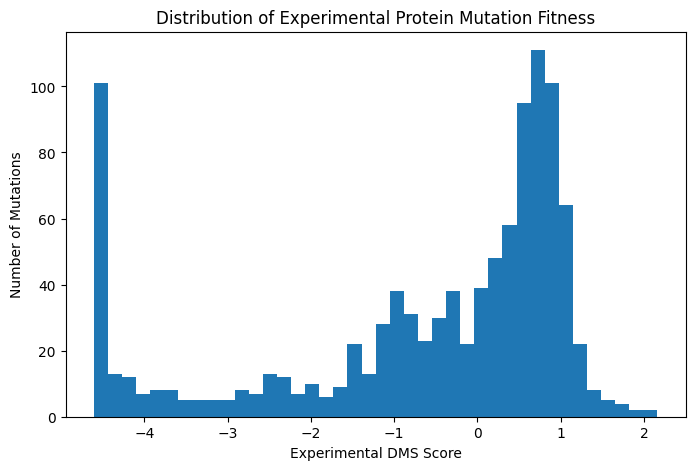

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(
    single_mutants["DMS_score"],
    bins=40
)

plt.xlabel("Experimental DMS Score")
plt.ylabel("Number of Mutations")
plt.title("Distribution of Experimental Protein Mutation Fitness")

plt.show()

In [23]:
top_experimental = (
    single_mutants
    .sort_values("DMS_score", ascending=False)
    .head(10)
    [["mutant", "DMS_score"]]
)

display(top_experimental)

,mutant,DMS_score
235631,A250Y,2.161161
232838,A250W,2.003222
231910,A250H,1.861087
227301,A250F,1.842672
226533,A250E,1.807120
224891,A250P,1.790951
390100,D266W,1.761430
390501,D266Y,1.758863
222589,A250Q,1.576986
452428,D273R,1.575324


In [24]:
MAX_SAMPLES = 1500

if len(single_mutants) > MAX_SAMPLES:
    model_data = single_mutants.sample(
        n=MAX_SAMPLES,
        random_state=42
    ).reset_index(drop=True)
else:
    model_data = single_mutants.reset_index(drop=True)

print("Variants used for ML:", len(model_data))

Variants used for ML: 1045


In [25]:
train_df, test_df = train_test_split(
    model_data,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 836
Testing samples: 209


In [26]:
def get_esm_embedding(sequence):
    """
    Generate a fixed-length ESM-2 embedding for one protein sequence.
    Mean-pools residue embeddings while excluding special tokens.
    """

    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
        add_special_tokens=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = esm_model(**inputs)

    hidden = outputs.last_hidden_state

    # ESM adds beginning/end special tokens.
    # Keep only residue representations.
    residue_embeddings = hidden[:, 1:-1, :]

    embedding = residue_embeddings.mean(dim=1)

    return embedding.squeeze(0).cpu().numpy()

In [27]:
def embed_dataframe(df, sequence_column="mutated_sequence"):
    embeddings = []

    for sequence in tqdm(df[sequence_column], desc="Generating ESM-2 embeddings"):
        emb = get_esm_embedding(sequence)
        embeddings.append(emb)

    return np.vstack(embeddings)

In [28]:
X_train = embed_dataframe(train_df)
X_test = embed_dataframe(test_df)

y_train = train_df["DMS_score"].values
y_test = test_df["DMS_score"].values

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Generating ESM-2 embeddings:   0%|          | 0/836 [00:00<?, ?it/s]

Generating ESM-2 embeddings:   0%|          | 0/209 [00:00<?, ?it/s]

Training features: (836, 320)
Testing features: (209, 320)


In [29]:
os.makedirs("results", exist_ok=True)

np.save("results/X_train_esm.npy", X_train)
np.save("results/X_test_esm.npy", X_test)
np.save("results/y_train.npy", y_train)
np.save("results/y_test.npy", y_test)

print("Embeddings saved.")

Embeddings saved.


In [30]:
baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

baseline_spearman = spearmanr(
    y_test,
    baseline_predictions
).statistic

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)
print("Baseline Spearman:", baseline_spearman)

Baseline MAE: 1.5208149127078618
Baseline RMSE: 1.8696063988558196
Baseline R²: -3.0843084674714305e-05
Baseline Spearman: nan


/tmp/ipykernel_1790/1771601358.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  baseline_spearman = spearmanr(


In [31]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Random Forest training complete.


In [32]:
rf_predictions = rf_model.predict(X_test)

In [33]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

rf_spearman = spearmanr(
    y_test,
    rf_predictions
).statistic

print("Random Forest + ESM-2 Results")
print("--------------------------------")
print(f"MAE:      {rf_mae:.4f}")
print(f"RMSE:     {rf_rmse:.4f}")
print(f"R²:       {rf_r2:.4f}")
print(f"Spearman: {rf_spearman:.4f}")

Random Forest + ESM-2 Results
--------------------------------
MAE:      1.0017
RMSE:     1.3163
R²:       0.5043
Spearman: 0.6246


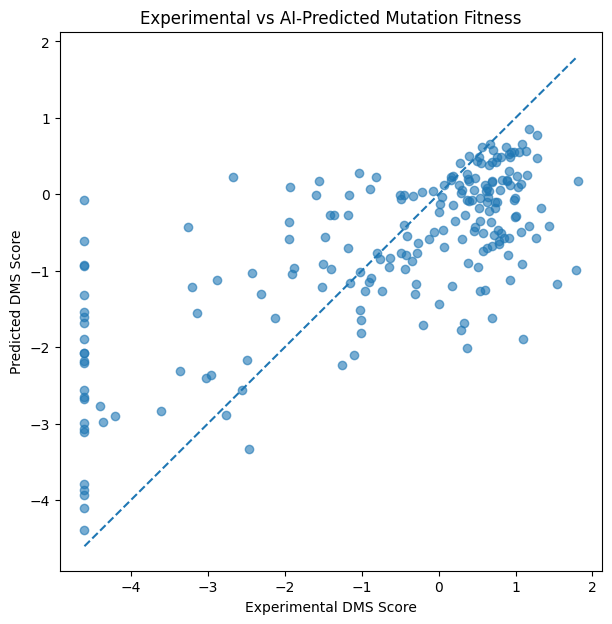

In [34]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

minimum = min(
    y_test.min(),
    rf_predictions.min()
)

maximum = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Experimental DMS Score")
plt.ylabel("Predicted DMS Score")
plt.title("Experimental vs AI-Predicted Mutation Fitness")

plt.show()

In [35]:
metrics_df = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "ESM-2 + Random Forest"
    ],
    "MAE": [
        baseline_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2
    ],
    "Spearman": [
        baseline_spearman,
        rf_spearman
    ]
})

display(metrics_df)

,Model,MAE,RMSE,R2,Spearman
0,Mean Baseline,1.520815,1.869606,-0.000031,NaN
1,ESM-2 + Random Forest,1.001697,1.316349,0.504259,0.624576


In [36]:
metrics_df.to_csv(
    "results/model_metrics.csv",
    index=False
)

In [37]:
results_df = test_df[
    ["mutant", "mutated_sequence", "DMS_score"]
].copy()

results_df["Predicted_DMS_score"] = rf_predictions

results_df["Absolute_Error"] = np.abs(
    results_df["DMS_score"] -
    results_df["Predicted_DMS_score"]
)

results_df = results_df.sort_values(
    "Predicted_DMS_score",
    ascending=False
).reset_index(drop=True)

results_df["AI_Rank"] = (
    np.arange(len(results_df)) + 1
)

display(
    results_df[
        [
            "AI_Rank",
            "mutant",
            "Predicted_DMS_score",
            "DMS_score",
            "Absolute_Error"
        ]
    ].head(15)
)

,AI_Rank,mutant,Predicted_DMS_score,DMS_score,Absolute_Error
0,1,D262N,0.855233,1.169513,0.314280
1,2,D266A,0.773700,1.276065,0.502366
2,3,Q228N,0.657464,0.670909,0.013445
3,4,D273A,0.652798,1.087164,0.434367
4,5,Q228Y,0.622400,0.878481,0.256081
5,6,K230R,0.614384,0.567879,0.046505
6,7,T277C,0.577964,0.707560,0.129596
7,8,T277V,0.563550,1.133987,0.570437
8,9,E268K,0.560245,1.043272,0.483027
9,10,D248G,0.553562,0.942192,0.388631


In [38]:
results_df.to_csv(
    "results/mutation_predictions.csv",
    index=False
)

In [39]:
top_candidates = results_df[
    [
        "AI_Rank",
        "mutant",
        "Predicted_DMS_score",
        "DMS_score"
    ]
].head(10)

display(top_candidates)

,AI_Rank,mutant,Predicted_DMS_score,DMS_score
0,1,D262N,0.855233,1.169513
1,2,D266A,0.773700,1.276065
2,3,Q228N,0.657464,0.670909
3,4,D273A,0.652798,1.087164
4,5,Q228Y,0.622400,0.878481
5,6,K230R,0.614384,0.567879
6,7,T277C,0.577964,0.707560
7,8,T277V,0.563550,1.133987
8,9,E268K,0.560245,1.043272
9,10,D248G,0.553562,0.942192


In [40]:
TOP_K = min(20, len(results_df))

top_k_actual_mean = (
    results_df
    .head(TOP_K)["DMS_score"]
    .mean()
)

overall_actual_mean = (
    results_df["DMS_score"]
    .mean()
)

print(
    f"Mean experimental fitness of AI Top {TOP_K}: "
    f"{top_k_actual_mean:.4f}"
)

print(
    f"Mean experimental fitness of all test variants: "
    f"{overall_actual_mean:.4f}"
)

print(
    "Improvement:",
    round(
        top_k_actual_mean -
        overall_actual_mean,
        4
    )
)

Mean experimental fitness of AI Top 20: 0.8648
Mean experimental fitness of all test variants: -0.6647
Improvement: 1.5295


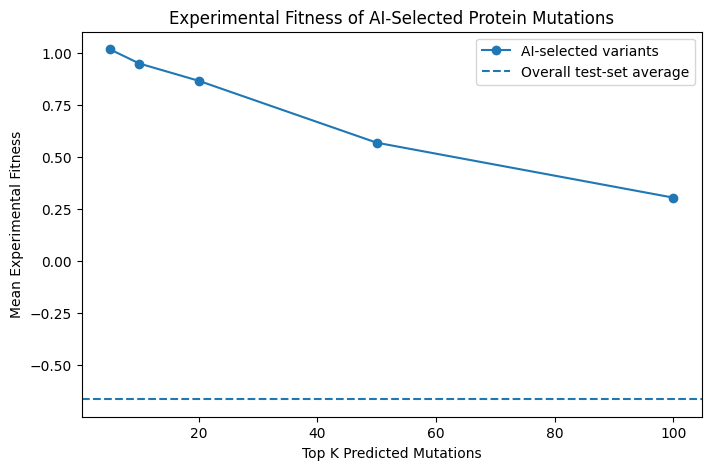

In [41]:
top_sizes = [
    k for k in [5, 10, 20, 50, 100]
    if k <= len(results_df)
]

top_means = []

for k in top_sizes:
    top_means.append(
        results_df.head(k)["DMS_score"].mean()
    )

plt.figure(figsize=(8, 5))

plt.plot(
    top_sizes,
    top_means,
    marker="o",
    label="AI-selected variants"
)

plt.axhline(
    results_df["DMS_score"].mean(),
    linestyle="--",
    label="Overall test-set average"
)

plt.xlabel("Top K Predicted Mutations")
plt.ylabel("Mean Experimental Fitness")
plt.title("Experimental Fitness of AI-Selected Protein Mutations")

plt.legend()
plt.show()

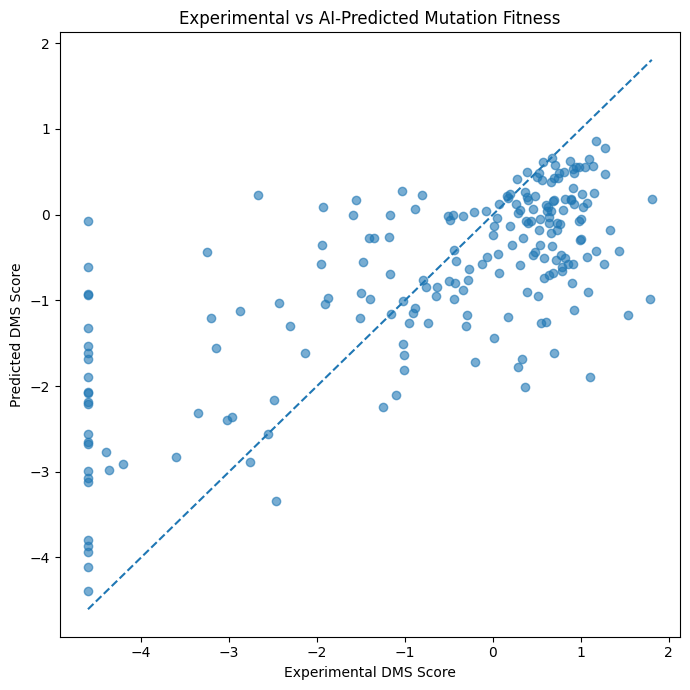

In [42]:
os.makedirs(
    "results/figures",
    exist_ok=True
)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

minimum = min(
    y_test.min(),
    rf_predictions.min()
)

maximum = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Experimental DMS Score")
plt.ylabel("Predicted DMS Score")
plt.title("Experimental vs AI-Predicted Mutation Fitness")

plt.tight_layout()

plt.savefig(
    "results/figures/predicted_vs_experimental.png",
    dpi=300
)

plt.show()

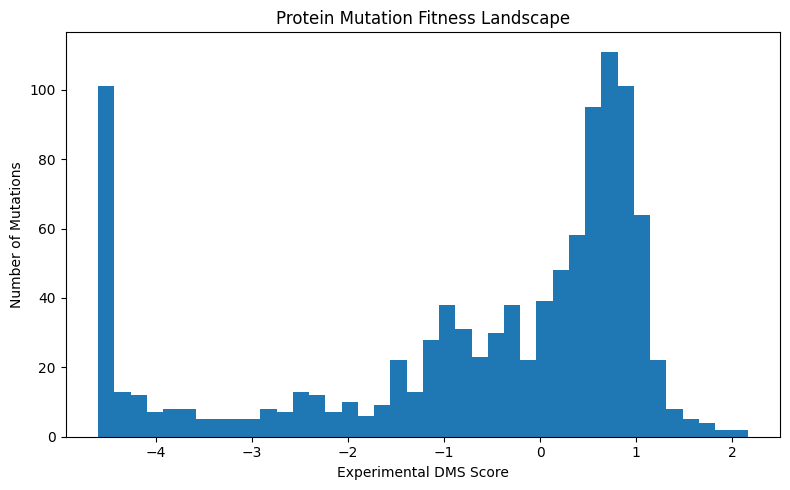

In [43]:
plt.figure(figsize=(8, 5))

plt.hist(
    single_mutants["DMS_score"],
    bins=40
)

plt.xlabel("Experimental DMS Score")
plt.ylabel("Number of Mutations")
plt.title("Protein Mutation Fitness Landscape")

plt.tight_layout()

plt.savefig(
    "results/figures/fitness_distribution.png",
    dpi=300
)

plt.show()

## Baseline Comparison

To evaluate whether protein language model representations provide useful
information beyond simple mutation identity, I compare the ESM-2 model against
a lightweight baseline based only on basic mutation characteristics.

This comparison helps determine whether learned protein representations improve
prediction of experimental mutation fitness.


In [44]:
import re

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def parse_mutation(mutation):
    """
    Parse a single mutation such as A42V.

    Returns:
        original amino acid
        position
        mutated amino acid
    """

    match = re.fullmatch(
        r"([A-Z])(\d+)([A-Z])",
        str(mutation)
    )

    if match is None:
        return None, None, None

    original = match.group(1)
    position = int(match.group(2))
    new = match.group(3)

    return original, position, new

In [45]:
print(parse_mutation("A42V"))

('A', 42, 'V')


In [46]:
def create_baseline_features(df):

    features = []

    for mutation in df["mutant"]:

        original, position, new = parse_mutation(mutation)

        row = []

        # Normalized mutation position
        row.append(position / len(WT_SEQUENCE))

        # One-hot encoding of original amino acid
        for aa in AMINO_ACIDS:
            row.append(1 if original == aa else 0)

        # One-hot encoding of new amino acid
        for aa in AMINO_ACIDS:
            row.append(1 if new == aa else 0)

        features.append(row)

    return np.array(features)

In [47]:
X_train_baseline = create_baseline_features(train_df)
X_test_baseline = create_baseline_features(test_df)

print("Baseline feature shape:", X_train_baseline.shape)

Baseline feature shape: (836, 41)


In [48]:
baseline_feature_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

baseline_feature_model.fit(
    X_train_baseline,
    y_train
)

baseline_feature_predictions = baseline_feature_model.predict(
    X_test_baseline
)

In [49]:
simple_mae = mean_absolute_error(
    y_test,
    baseline_feature_predictions
)

simple_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_feature_predictions
    )
)

simple_r2 = r2_score(
    y_test,
    baseline_feature_predictions
)

simple_spearman = spearmanr(
    y_test,
    baseline_feature_predictions
).statistic

print("Simple Mutation Feature Model")
print("--------------------------------")
print(f"MAE:      {simple_mae:.4f}")
print(f"RMSE:     {simple_rmse:.4f}")
print(f"R²:       {simple_r2:.4f}")
print(f"Spearman: {simple_spearman:.4f}")

Simple Mutation Feature Model
--------------------------------
MAE:      0.5525
RMSE:     0.9000
R²:       0.7683
Spearman: 0.8726


In [50]:
comparison_df = pd.DataFrame({
    "Model": [
        "Mean Prediction",
        "Basic Mutation Features + Random Forest",
        "ESM-2 Embeddings + Random Forest"
    ],

    "MAE": [
        baseline_mae,
        simple_mae,
        rf_mae
    ],

    "RMSE": [
        baseline_rmse,
        simple_rmse,
        rf_rmse
    ],

    "R2": [
        baseline_r2,
        simple_r2,
        rf_r2
    ],

    "Spearman": [
        baseline_spearman,
        simple_spearman,
        rf_spearman
    ]
})

display(
    comparison_df.round(4)
)

comparison_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

,Model,MAE,RMSE,R2,Spearman
0,Mean Prediction,1.5208,1.8696,-0.0000,NaN
1,Basic Mutation Features + Random Forest,0.5525,0.9000,0.7683,0.8726
2,ESM-2 Embeddings + Random Forest,1.0017,1.3163,0.5043,0.6246


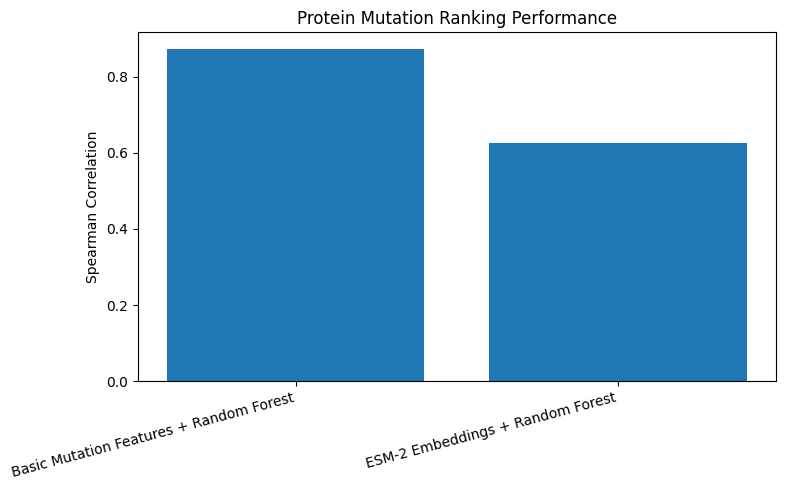

In [51]:
plot_df = comparison_df[
    comparison_df["Model"] != "Mean Prediction"
].copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["Model"],
    plot_df["Spearman"]
)

plt.ylabel("Spearman Correlation")
plt.title("Protein Mutation Ranking Performance")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "results/figures/model_comparison.png",
    dpi=300
)

plt.show()

## Final Model Comparison

To determine whether pretrained protein language model representations
provided an advantage over simpler biological features, I compared two
Random Forest models using the same train/test split.

The first model used 320-dimensional sequence embeddings generated by ESM-2.

The second model used interpretable mutation-level features including
mutation position, original amino acid, and substituted amino acid.

In [53]:
final_results = pd.DataFrame({
    "Model": [
        "ESM-2 Embeddings + Random Forest",
        "Mutation Features + Random Forest"
    ],
    "MAE": [
        1.0017,
        0.5525
    ],
    "RMSE": [
        1.3163,
        0.9000
    ],
    "R2": [
        0.5043,
        0.7683
    ],
    "Spearman": [
        0.6246,
        0.8726
    ]
})

display(final_results)

final_results.to_csv(
    "results/final_model_results.csv",
    index=False
)

,Model,MAE,RMSE,R2,Spearman
0,ESM-2 Embeddings + Random Forest,1.0017,1.3163,0.5043,0.6246
1,Mutation Features + Random Forest,0.5525,0.9000,0.7683,0.8726


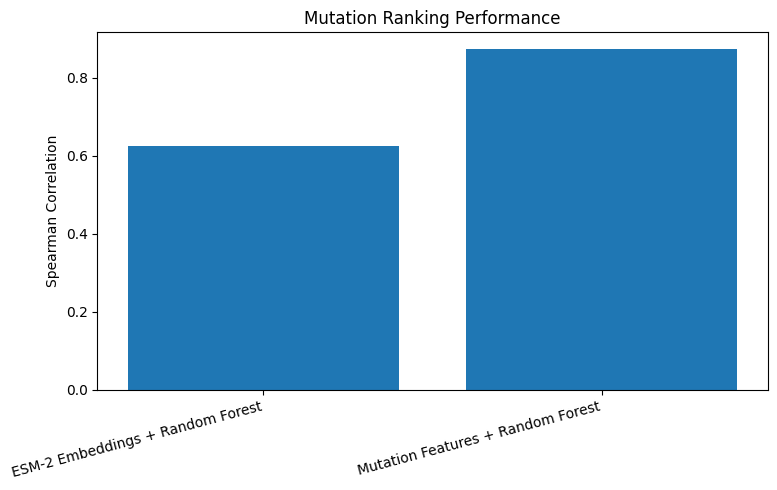

In [54]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_results["Model"],
    final_results["Spearman"]
)

plt.ylabel("Spearman Correlation")
plt.title("Mutation Ranking Performance")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "results/figures/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusions

This project developed and evaluated machine-learning approaches for
predicting experimentally measured protein mutation fitness.

A pretrained ESM-2 protein language model was used to generate
320-dimensional representations of mutated protein sequences. These
representations were used to train a Random Forest regression model.

The ESM-2 model achieved:

- R² = 0.5043
- Spearman correlation = 0.6246
- MAE = 1.0017
- RMSE = 1.3163

To determine whether the protein language model provided additional predictive
value, I developed a second model using interpretable mutation-level features,
including mutation position, original amino acid, and substituted amino acid.

The mutation-feature model achieved:

- R² = 0.7683
- Spearman correlation = 0.8726
- MAE = 0.5525
- RMSE = 0.9000

Interestingly, the simpler mutation-feature model substantially outperformed
the pooled ESM-2 representations on this dataset.

This demonstrates an important principle in applied machine learning:
state-of-the-art pretrained models should be evaluated against strong,
interpretable baselines rather than assumed to provide superior performance.

Despite moderate regression performance from ESM-2, the protein-language-model
pipeline demonstrated the ability to prioritize promising variants. The top
20 mutations selected by the ESM-based model had an average experimentally
measured DMS score of 0.8648 compared with -0.6647 across the entire held-out
test set.

Overall, this project demonstrates how experimental protein-engineering data,
protein language models, interpretable biological features, and supervised
machine learning can be integrated into a computational workflow for
prioritizing protein variants for further experimental investigation.